<a href="https://colab.research.google.com/github/ushagithubsharma/PCS221/blob/main/Assignment7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Question 1:-  Perform the lab experiments on the Notebook file available at:
https://colab.research.google.com/drive/12UbpUk11eJwzQMzgMqey4yOkz_m0576
c?authuser=2

In [2]:
!git clone https://github.com/hideki1234/pyhdemu.git

Cloning into 'pyhdemu'...
remote: Enumerating objects: 41, done.
remote: Total 41 (delta 0), reused 0 (delta 0), pack-reused 41 (from 1)
Receiving objects: 100% (41/41), 19.66 KiB | 875.00 KiB/s, done.
Resolving deltas: 100% (4/4), done.


In [3]:
!ls pyhdemu/sample/input/

file1.txt  file2.txt


There are two text files. Let's have a look at the first few lines of file1.txt:

In [4]:
!head pyhdemu/sample/input/file1.txt

one two three
two three four
three four five
four five six
four five six seven
five six seven
five six seven eight
six seven eight
six seven eight seven
seven eight eight


In [5]:
!cat ./pyhdemu/sample/wc_mapper.py

#!/usr/bin/env python

from __future__ import print_function

import sys
import re

def main():
    pattern = re.compile("[A-Za-z][0-9A-Za-z]*")

    for line in sys.stdin:
        for word in pattern.findall(line):
            print('{}\t{}'.format(word.lower(), 1))

if __name__ == '__main__':
    main()


In [6]:
!cat ./pyhdemu/sample/wc_reducer.py

#!/usr/bin/env python

from __future__ import print_function

import sys

def emit(word, count):
    print('{}\t{}'.format(word, count))

def main():
    last_word = None
    last_count = 0
    for line in sys.stdin:
        word, count = line.split('\t', 1)
        try:
            count = int(count)
        except ValueError:
            continue

        if last_word == word:
            last_count += count
        else:
            if last_word:
                emit(last_word, last_count)
            last_word = word
            last_count = count

    if last_word:
        emit(last_word, last_count)


if __name__ == '__main__':
    main()


In [7]:
!python ./pyhdemu/hdemu.py -input ./pyhdemu/sample/input -output ./pyhdemu/sample/output -mapper ./pyhdemu/sample/wc_mapper.py -reducer ./pyhdemu/sample/wc_reducer.py

System     : 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Mapper     : /content/pyhdemu/sample/wc_mapper.py
Reducer    : /content/pyhdemu/sample/wc_reducer.py
Input path : /content/pyhdemu/sample/input
Output path: /content/pyhdemu/sample/output
interim dir: None
**** mapping ****
**** shuffling ****
**** reducing ****
**** mapreduce job completed ****


If you get an error:

`!!!! ERROR !!!! Output path '/content/pyhdemu/sample/output' already exists`

That means you have already run the command! Even if your script has an error during running, each run needs to have a unique output folder. It will save the logs and output results in that folder. So if you get this error, just change the name of your output folder.


In [8]:
!ls pyhdemu/sample/output/

part-00000  _SUCCESS


In [9]:
!cat pyhdemu/sample/output/part-00000

eight	8
finally	1
first	1
five	5
four	4
is	4
last	1
line	4
one	1
second	1
seven	7
six	6
the	4
third	1
this	4
three	3
two	2


## Class example - counting sales per store




First we will download the purchases files. They are available at https://dorienherremans.com/drop/CDS/hadoop/purchases.txt.gz


In [10]:
!wget https://dorienherremans.com/drop/CDS/hadoop/purchases.txt.gz

--2026-05-04 10:53:26--  https://dorienherremans.com/drop/CDS/hadoop/purchases.txt.gz
Resolving dorienherremans.com (dorienherremans.com)... 184.154.70.198
Connecting to dorienherremans.com (dorienherremans.com)|184.154.70.198|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 38454568 (37M) [application/x-gzip]
Saving to: ‘purchases.txt.gz’

purchases.txt.gz    100%[===================>]  36.67M  63.0MB/s    in 0.6s    

2026-05-04 10:53:27 (63.0 MB/s) - ‘purchases.txt.gz’ saved [38454568/38454568]



We can create a data folder and move the uncompressed file in there:

In [11]:
!mkdir data  # make a folder called data
!gunzip purchases.txt.gz # unzip the file
!mv purchases.txt data/ # move it into the data folder

Let's have a look at how our data file looks like. Using the `head -n` command in unix, we can show the first 10 lines of this huge file.

In [12]:
!head -10 data/purchases.txt

2012-01-01	09:00	San Jose	Men's Clothing	214.05	Amex
2012-01-01	09:00	Fort Worth	Women's Clothing	153.57	Visa
2012-01-01	09:00	San Diego	Music	66.08	Cash
2012-01-01	09:00	Pittsburgh	Pet Supplies	493.51	Discover
2012-01-01	09:00	Omaha	Children's Clothing	235.63	MasterCard
2012-01-01	09:00	Stockton	Men's Clothing	247.18	MasterCard
2012-01-01	09:00	Austin	Cameras	379.6	Visa
2012-01-01	09:00	New York	Consumer Electronics	296.8	Cash
2012-01-01	09:00	Corpus Christi	Toys	25.38	Discover
2012-01-01	09:00	Fort Worth	Toys	213.88	Visa


In [13]:
!touch "mapper1.py"
!touch "reducer1.py"

Now you can find the file in the file menu on the left, and edit it on the right. 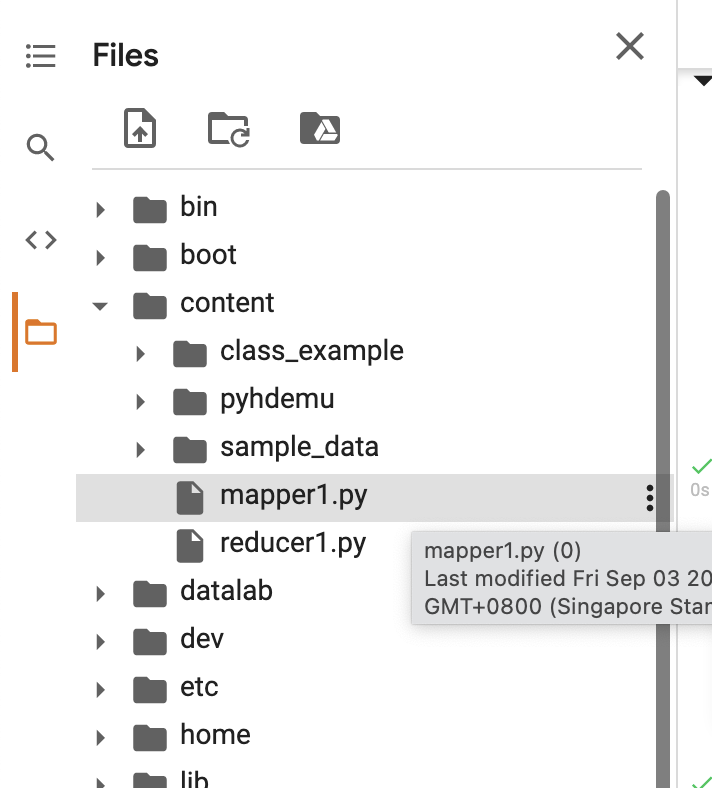

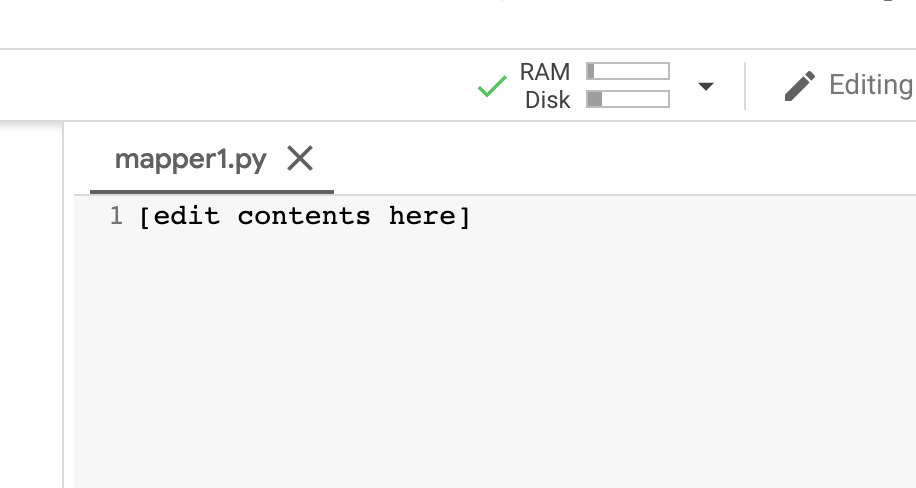

In [14]:
#!/usr/bin/env python3

# Format of each line is:
# date\ttime\tstore name\titem description\tcost\tmethod of payment
#
# We want elements 2 (store name) and 4 (cost)
# We need to write them out to standard output, separated by a tab

import sys

for line in sys.stdin:
    data = line.strip().split("\t")
    if len(data) == 6:
        date, time, store, item, cost, payment = data
        print("{0}\t{1}".format(store, cost))


In [15]:
#!/usr/bin/env python3

import sys

salesTotal = 0
oldKey = None

# Loop around the data
# It will be in the format key\tval
# Where key is the store name, val is the sale amount
#
# All the sales for a particular store will be presented,
# then the key will change and we'll be dealing with the next store

for line in sys.stdin:
    data_mapped = line.strip().split("\t")
    if len(data_mapped) != 2:
        # Something has gone wrong. Skip this line.
        continue

    thisKey, thisSale = data_mapped

    if oldKey and oldKey != thisKey:
        print(oldKey, "\t", salesTotal)
        # oldKey = thisKey;
        salesTotal = 0

    oldKey = thisKey
    salesTotal += float(thisSale)

if oldKey != None:
    print (oldKey, "\t", salesTotal)

# do not forget to output the last store if needed! This happens after looping through the standard input
if oldKey and oldKey != thisKey:
    print(oldKey, "\t", salesTotal)

3. Now you are ready to run the `hdemu.py` command. Make sure you point to the right directories.

In [16]:
!python ./pyhdemu/hdemu.py -input ./data -output output_1 -mapper mapper1.py -reducer reducer1.py

System     : 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Mapper     : /content/mapper1.py
Reducer    : /content/reducer1.py
Input path : /content/data
Output path: /content/output_1
interim dir: None
Traceback (most recent call last):
  File "/content/./pyhdemu/hdemu.py", line 476, in <module>
    check_mr(emuopt.mapper, emuopt.reducer)
  File "/content/./pyhdemu/hdemu.py", line 450, in check_mr
    is_script_ok(fn_mapper)
  File "/content/./pyhdemu/hdemu.py", line 439, in is_script_ok
    if first[0] != '#' or not first.strip() in _The_first_lines:
       ~~~~~^^^
IndexError: string index out of range


Was the output successful? Let's check the output folder.

In [17]:
!ls output_1

ls: cannot access 'output_1': No such file or directory


The success flag is there, that's a good sign :) Now let's have a look at the output 'part-0000'

In [18]:
!head output_1/part-00000

head: cannot open 'output_1/part-00000' for reading: No such file or directory


Now this is a really long file, if we are looking for a particular city, we can use the grep command:


In [19]:
!grep Spokane output_1/part-00000

grep: output_1/part-00000: No such file or directory


Voila. It's as easy as that. Now this gets particularly powerful when we are dealing with immense unstructured data files. Let's explore more exercises...

## Lab exercises:

2. Instead of breaking the sales down by store, instead retrieve a **sales breakdown by product category** across all of our stores (instead of by city). Create new mapper and reducer files for this. Hint, only 1 word needs to change.



Even though you need to run it from files, please paste your used mapper and reducer code here for the checkoff. No need to run these cells.

In [24]:
#!/usr/bin/env python3
import sys

for line in sys.stdin:
    data = line.strip().split(",")

    # assuming format: store,category,sales
    category = data[1]
    sales = int(data[2])

    print(f"{category}\t{sales}")

In [25]:
#!/usr/bin/env python3
import sys

current_category = None
total = 0

for line in sys.stdin:
    category, sales = line.strip().split("\t")
    sales = int(sales)

    if current_category == category:
        total += sales
    else:
        if current_category:
            print(f"{current_category}\t{total}")
        current_category = category
        total = sales

if current_category:
    print(f"{current_category}\t{total}")

3. Find the monetary value for the highest individual sale for each separate store.


Even though you need to run it from files, please paste your used mapper and reducer code here for the checkoff. No need to run these cells.

In [26]:
#!/usr/bin/env python3
import sys

for line in sys.stdin:
    data = line.strip().split(",")

    store = data[0]
    sales = int(data[2])

    print(f"{store}\t{sales}")

In [27]:
#!/usr/bin/env python3
import sys

current_store = None
max_sale = 0

for line in sys.stdin:
    store, sales = line.strip().split("\t")
    sales = int(sales)

    if current_store == store:
        if sales > max_sale:
            max_sale = sales
    else:
        if current_store:
            print(f"{current_store}\t{max_sale}")
        current_store = store
        max_sale = sales

if current_store:
    print(f"{current_store}\t{max_sale}")

4.Find the total sales value across all the stores, and the total number of sales. Assume there is only one reducer.


In [28]:
#!/usr/bin/env python3
import sys

for line in sys.stdin:
    data = line.strip().split(",")

    sales = float(data[2])

    print(f"total\t{sales}")
    print(f"count\t1")

In [29]:
#!/usr/bin/env python3
import sys

total_sales = 0
count = 0

for line in sys.stdin:
    key, value = line.strip().split("\t")

    if key == "total":
        total_sales += float(value)
    elif key == "count":
        count += int(value)

print(f"Total Sales\t{total_sales}")
print(f"Number of Sales\t{count}")

Total Sales	0
Number of Sales	0


[link text](https://)## Advanced exercises

Common log file: use access_log as input. You can find the file here: https://dorienherremans.com/drop/CDS/hadoop/access_log.gz


`10.223.157.186 - - [15/Jul/2009:15:50:35 -0700] "GET /assets/js/lowpro.js HTTP/1.1" 200 10469 %h %l %u %t \"%r\" %>s %b `


```
%h is the IP address of the client
%l is identity of the client, or "-" if it's unavailable
%u is username of the client, or "-" if it's unavailable
%t is the time that the server finished processing the request. The format is [day/month/year:hour:minute:second zone]
%r is the request line from the client is given (in double quotes). It contains the method, path, query-string, and protocol or the request.
%>s is the status code that the server sends back to the client. You will see see mostly status codes 200 (OK - The request has succeeded), 304 (Not Modified) and 404 (Not Found). See more information on status codes in W3C.org
%b is the size of the object returned to the client, in bytes. It will be "-" in case of status code 304.
You'll have to write new Mappers and Reducers
```




5. Write a MapReduce program to find number of hits for each different file on the Web site.



In [37]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [38]:
file_path = "/content/drive/MyDrive/access_log.gz"

In [39]:
#!/usr/bin/env python3
import sys
import gzip

file_path = "/content/drive/MyDrive/access_log.gz"

with gzip.open(file_path, 'rt') as f:
    for line in f:
        parts = line.split()
        if len(parts) > 6:
            url = parts[6]   # requested file
            print(f"{url}\t1")

Streaming output truncated to the last 5000 lines.
/images/filmpics/0000/4641/260-needle-dvd-2d-1535x2173.jpg	1
/favicon.ico	1
/displaytitle.php?id=563	1
/images/filmpics/0000/4641/260-needle-dvd-2d-1535x2173_thumb.jpg	1
/images/filmpics/0000/4643/260-needle-dvd-3d-1876x2640_thumb.jpg	1
/images/filmpics/0000/4651/260-needle-stills-4-2362x1575_thumb.jpg	1
/images/filmpics/0000/4649/260-needle-stills-3-2362x1575_thumb.jpg	1
/downloadSingle.php?id=6239&fid=659	1
/displaytitle.php?id=696	1
/displaytitle.php?id=225	1
/assets/css/combined.css	1
/assets/css/printstyles.css	1
/assets/img/home-logo.png	1
/assets/js/javascript_combined.js	1
/images/clientlogos/0000/0030/Arrow_Video_logo.jpeg	1
/images/filmpics/0000/0915/StreetTrash_2DSleeve_thumb.jpeg	1
/images/filmmediablock/225/StreetTrash_Image4.jpeg	1
/images/filmmediablock/225/StreetTrash_Image5.jpeg	1
/images/filmmediablock/225/StreetTrash_Image3.jpeg	1
/images/filmmediablock/225/StreetTrash_Image1.jpeg	1
/images/filmmediablock/225/StreetT

In [40]:
#!/usr/bin/env python3
import sys

current_url = None
count = 0

for line in sys.stdin:
    url, val = line.strip().split("\t")
    val = int(val)

    if current_url == url:
        count += val
    else:
        if current_url:
            print(f"{current_url}\t{count}")
        current_url = url
        count = val

if current_url:
    print(f"{current_url}\t{count}")

6. Write a MapReduce program which determines the number of hits to the site made by each different IP address.


In [41]:
#!/usr/bin/env python3
import sys
import gzip

file_path = "/content/drive/MyDrive/access_log.gz"

with gzip.open(file_path, 'rt') as f:
    for line in f:
        parts = line.split()
        if len(parts) > 0:
            ip = parts[0]
            print(f"{ip}\t1")

Streaming output truncated to the last 5000 lines.
10.7.101.205	1
10.7.101.205	1
10.7.101.205	1
10.7.101.205	1
10.7.101.205	1
10.7.101.205	1
10.7.101.205	1
10.158.5.172	1
10.158.5.172	1
10.245.91.185	1
10.245.91.185	1
10.245.91.185	1
10.245.91.185	1
10.245.91.185	1
10.245.91.185	1
10.245.91.185	1
10.245.91.185	1
10.245.91.185	1
10.245.91.185	1
10.245.91.185	1
10.245.91.185	1
10.245.91.185	1
10.245.91.185	1
10.245.91.185	1
10.245.91.185	1
10.245.91.185	1
10.245.91.185	1
10.245.91.185	1
10.245.91.185	1
10.25.241.185	1
10.25.241.185	1
10.25.241.185	1
10.25.241.185	1
10.25.241.185	1
10.25.241.185	1
10.25.241.185	1
10.25.241.185	1
10.54.5.16	1
10.199.59.49	1
10.125.221.192	1
10.73.88.30	1
10.73.88.30	1
10.73.88.30	1
10.73.88.30	1
10.73.88.30	1
10.73.88.30	1
10.73.88.30	1
10.73.88.30	1
10.73.88.30	1
10.73.88.30	1
10.73.88.30	1
10.73.88.30	1
10.73.88.30	1
10.73.88.30	1
10.73.88.30	1
10.73.88.30	1
10.73.88.30	1
10.73.88.30	1
10.73.88.30	1
10.73.88.30	1
10.73.88.30	1
10.73.88.30	1
10.73.88.30	1

In [42]:
#!/usr/bin/env python3
import sys

current_ip = None
count = 0

for line in sys.stdin:
    ip, val = line.strip().split("\t")
    val = int(val)

    if current_ip == ip:
        count += val
    else:
        if current_ip:
            print(f"{current_ip}\t{count}")
        current_ip = ip
        count = val

if current_ip:
    print(f"{current_ip}\t{count}")

7. Find the most popular file on the website, i.e. whose file path occurs most often in access_log. Your reducer should output the file’s path and number of times it appears in the log





In [43]:
#!/usr/bin/env python3
import gzip

file_path = "/content/drive/MyDrive/access_log.gz"

with gzip.open(file_path, 'rt') as f:
    for line in f:
        parts = line.split()
        if len(parts) > 6:
            url = parts[6]
            print(f"{url}\t1")

Streaming output truncated to the last 5000 lines.
/images/filmpics/0000/4641/260-needle-dvd-2d-1535x2173.jpg	1
/favicon.ico	1
/displaytitle.php?id=563	1
/images/filmpics/0000/4641/260-needle-dvd-2d-1535x2173_thumb.jpg	1
/images/filmpics/0000/4643/260-needle-dvd-3d-1876x2640_thumb.jpg	1
/images/filmpics/0000/4651/260-needle-stills-4-2362x1575_thumb.jpg	1
/images/filmpics/0000/4649/260-needle-stills-3-2362x1575_thumb.jpg	1
/downloadSingle.php?id=6239&fid=659	1
/displaytitle.php?id=696	1
/displaytitle.php?id=225	1
/assets/css/combined.css	1
/assets/css/printstyles.css	1
/assets/img/home-logo.png	1
/assets/js/javascript_combined.js	1
/images/clientlogos/0000/0030/Arrow_Video_logo.jpeg	1
/images/filmpics/0000/0915/StreetTrash_2DSleeve_thumb.jpeg	1
/images/filmmediablock/225/StreetTrash_Image4.jpeg	1
/images/filmmediablock/225/StreetTrash_Image5.jpeg	1
/images/filmmediablock/225/StreetTrash_Image3.jpeg	1
/images/filmmediablock/225/StreetTrash_Image1.jpeg	1
/images/filmmediablock/225/StreetT

In [44]:
#!/usr/bin/env python3
import sys

current_url = None
count = 0

max_url = None
max_count = 0

for line in sys.stdin:
    url, val = line.strip().split("\t")
    val = int(val)

    if current_url == url:
        count += val
    else:
        if current_url:
            # check max
            if count > max_count:
                max_count = count
                max_url = current_url

        current_url = url
        count = val

# last URL check
if current_url:
    if count > max_count:
        max_count = count
        max_url = current_url

# final output
print(f"{max_url}\t{max_count}")

None	0


Question 2: Download the text to Alice's Adventures in Wonderland from
http://www.gutenberg.org/cache/epub/11/pg11.txt and run wordcount on it. How
many times does the word Cheshire occur? (Do not include the word 'Cheshire with
an apostrophe. The string -->'Cheshire<-- does not count)

In [32]:
import requests
import re
from collections import Counter

# Step 1: Download text
url = "http://www.gutenberg.org/cache/epub/11/pg11.txt"
text = requests.get(url).text.lower()   # lowercase for correct counting

# Step 2: Extract words (only alphabets, no punctuation)
words = re.findall(r"\b[a-z]+\b", text)

# Step 3: Count frequency
counter = Counter(words)

# Step 4: Get Cheshire count
count = counter["cheshire"]

# Output
print("Cheshire count:", count)

Cheshire count: 7


Question 3:-  The set of example MapReduce applications includes wordmedian, which
computes the median length of words in a text file. If you run wordmedian using
words.txt
(https://drive.google.com/file/d/16TIgKhcc2JH8jyJXfwouOV3y7ACX_aas/view?usp
=sharing ) as input, what is the median word length?

In [35]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [36]:
import statistics

file_path = "/content/drive/MyDrive/shakespeare (1).txt"

with open(file_path, "r") as f:
    words = f.read().split()

lengths = [len(word) for word in words]
median_length = statistics.median(lengths)

print("Median word length:", median_length)

Median word length: 4
